<div style="background: linear-gradient(90deg, #0b6623 0%, #2e8b57 50%, #98fb98 100%); padding: 20px; border-radius: 12px; text-align: center;">
  <h1 style="color: white; margin: 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, 'Helvetica Neue', Arial; font-weight: 700; font-size: 2.2rem;">
    Lab 3 Part 3
  </h1>
</div>

## Practical Work 3

For this practical work, the trainees will have to develop a Python program that is able to implement the accelerated gradient descent methods <b>(Momentum and NAG)</b> in order to achieve the linear regression of a set of datapoints.

##### Please notice that we will apply these algorithm to single variable LR.
##### Only batch variant is required.

#### Import numpy, matplotlib.pyplot and make it inline

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
%matplotlib inline

To have a dataset or set of data points, the student must generate a pair of arrays <b>X</b> and <b>y</b> with the values in <b>X</b> equally distributed between <b>0</b> and <b>20</b> and the values in <b>y</b> such that:
<b>yi = a*xi + b (and a = -1, b = 2)</b>


In [2]:
X = np.linspace(0,20)
X

array([ 0.        ,  0.40816327,  0.81632653,  1.2244898 ,  1.63265306,
        2.04081633,  2.44897959,  2.85714286,  3.26530612,  3.67346939,
        4.08163265,  4.48979592,  4.89795918,  5.30612245,  5.71428571,
        6.12244898,  6.53061224,  6.93877551,  7.34693878,  7.75510204,
        8.16326531,  8.57142857,  8.97959184,  9.3877551 ,  9.79591837,
       10.20408163, 10.6122449 , 11.02040816, 11.42857143, 11.83673469,
       12.24489796, 12.65306122, 13.06122449, 13.46938776, 13.87755102,
       14.28571429, 14.69387755, 15.10204082, 15.51020408, 15.91836735,
       16.32653061, 16.73469388, 17.14285714, 17.55102041, 17.95918367,
       18.36734694, 18.7755102 , 19.18367347, 19.59183673, 20.        ])

In [4]:
a=-1
b=2
y=a*X+b
y

array([  2.        ,   1.59183673,   1.18367347,   0.7755102 ,
         0.36734694,  -0.04081633,  -0.44897959,  -0.85714286,
        -1.26530612,  -1.67346939,  -2.08163265,  -2.48979592,
        -2.89795918,  -3.30612245,  -3.71428571,  -4.12244898,
        -4.53061224,  -4.93877551,  -5.34693878,  -5.75510204,
        -6.16326531,  -6.57142857,  -6.97959184,  -7.3877551 ,
        -7.79591837,  -8.20408163,  -8.6122449 ,  -9.02040816,
        -9.42857143,  -9.83673469, -10.24489796, -10.65306122,
       -11.06122449, -11.46938776, -11.87755102, -12.28571429,
       -12.69387755, -13.10204082, -13.51020408, -13.91836735,
       -14.32653061, -14.73469388, -15.14285714, -15.55102041,
       -15.95918367, -16.36734694, -16.7755102 , -17.18367347,
       -17.59183673, -18.        ])

### Plot X vs. y

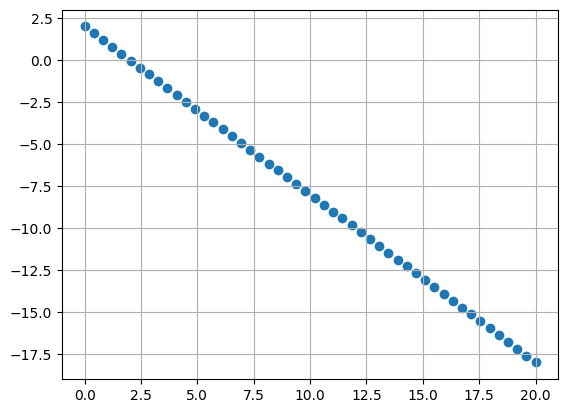

In [5]:
plt.scatter(X,y)
plt.grid(True)

#### Use your final version of the implemented Batch GD algorithm for single variable to find the best line filt of the given data.
#### Choose the suitable number of iterations, learning rate, and stop criteria.
#### Calculate r2 score. Shouldn't below 0.9
#### Plot the required curves (loss-epochs, loss-theta0, loss-theta1, all fitted lines per epoch (single graph), best fit line)

In [6]:
import numpy as np

def GD_1(X: np.array, y: np.array, alpha: float, max_iter: int):
    m = len(X)
    Xp = np.c_[np.ones((m, 1)), X]
    y = y.reshape(-1, 1)

    thetas = np.zeros((Xp.shape[1], 1))

    losses_history = []
    theta0_history = [thetas[0, 0]]
    theta1_history = [thetas[1, 0]]
    hyp = []
    grad = []
    prev_err=0
    for i in range(max_iter):

        hypothesis = Xp @ thetas
        hyp.append(hypothesis.copy())


        loss = np.mean((hypothesis - y) ** 2)
        losses_history.append(loss)


        gradient = (Xp.T @ (hypothesis - y)) / m
        grad.append(gradient.copy())


        thetas -= alpha * gradient


        theta0_history.append(thetas[0, 0])
        theta1_history.append(thetas[1, 0])

        if np.linalg.norm(gradient)<0.001:
          print("Gradient Check Passed")
          break
        if(np.abs(prev_err-loss)<0.001):
          print("Convergence Check Passed")
          break

        prev_err=loss

    grad_norm = np.linalg.norm(gradient)

    return theta0_history, theta1_history, losses_history, hyp, grad_norm, grad

#### Try your function with any input parameterss of your choice.
##### The following results uses alpha = 0.0005 and max. iterations = 300.

In [7]:
theta0h,theta1h,lossesh,hyph,grad_norm,grad=GD_1(X,y,0.0005,300)


for i in range(len(X)):
  print("\n")
  print(f"************* iteration {i} *************")
  print(f"h(x): {hyph[i].flatten()}\n")
  print(f"loss: {np.array(lossesh)}\n")
  print(f"j= {lossesh[-1]}")
  print(f"theta0: {theta0h[-1]}")
  print(f"theta1: {theta1h[-1]}")



Convergence Check Passed


************* iteration 0 *************
h(x): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]

loss: [98.69387755 85.92275966 74.82272979 65.17512296 56.78988689 49.50183803
 43.16740737 37.66181221 32.87659787 28.71750118 25.10259349 21.96066665
 19.22983025 16.85629234 14.79329975 13.00021706 11.44172605 10.08712999
  8.90974883  7.8863937   6.99691     6.22378041  5.5517798   4.96767525
  4.45996541  4.01865391  3.63505239  3.30160941  3.01176165  2.75980459
  2.54078018  2.35037912  2.18485601  2.04095552  1.91584832  1.80707527
  1.71249902  1.63026191  1.55874934  1.496558    1.44246821  1.39541986
  1.35449157  1.31888255  1.28789675  1.26092923  1.23745421  1.21701469
  1.19921347  1.18370535  1.17019027  1.15840746  1.14813024  1.13916162
  1.13133038  1.1244877   1.11850423  1.11326755  1.10867995  1.10465651
  1.10112341  1.09801651  1.09528004

In [8]:
y_pred1=theta0h[-1]+theta1h[-1]*X
r2_score(y,y_pred1)

0.9688648477999745

##### It is recommended to define a function for each plot. This will help you to easly plot the learning curves when you use different values of hyperparameters.

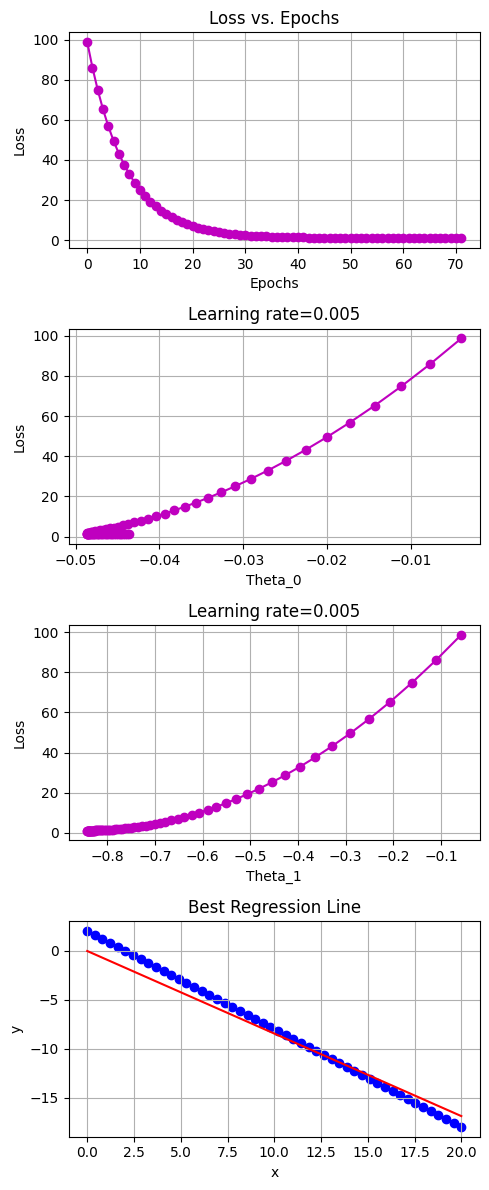

In [11]:
from matplotlib import markers
import matplotlib.pyplot as plt

fig,plots=plt.subplots(4,1,figsize=(5,12))
plots[0].plot(lossesh,color="m",marker="o",linestyle="-")
plots[0].set_title("Loss vs. Epochs")
plots[0].set_xlabel("Epochs")
plots[0].set_ylabel("Loss")
plots[0].grid(True)

plots[1].plot(theta0h[1:],lossesh,color="m",marker="o",linestyle="-")
plots[1].set_title("Learning rate=0.005")
plots[1].set_xlabel("Theta_0")
plots[1].set_ylabel("Loss")
plots[1].grid(True)

plots[2].plot(theta1h[1:],lossesh,color="m",marker="o",linestyle="-")
plots[2].set_title("Learning rate=0.005")
plots[2].set_xlabel("Theta_1")
plots[2].set_ylabel("Loss")
plots[2].grid(True)

plots[3].scatter(X,y,color="blue")
plots[3].plot(X,y_pred1,color="red")
plots[3].set_title("Best Regression Line")
plots[3].set_xlabel("x")
plots[3].set_ylabel("y")
plots[3].grid(True)

plt.tight_layout()
plt.show()

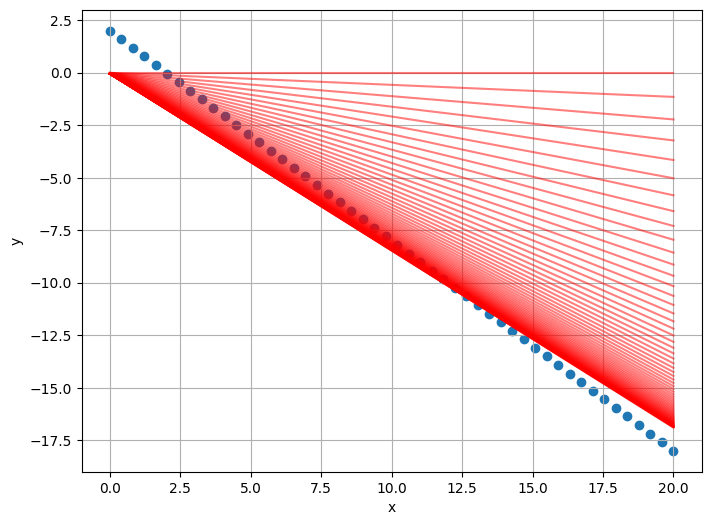

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_regression(x, y, theta0_history, theta1_history):
    plt.figure(figsize=(8, 6))

    plt.scatter(x, y, label='Data points')

    n_lines = len(theta0_history)
    step = max(1, n_lines // 50)

    for i in range(0, n_lines, step):
        y_pred = theta0_history[i] + theta1_history[i] * x
        plt.plot(x, y_pred, color='red', alpha=0.5)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()


plot_all_regression(X, y, theta0h, theta1h)

### Update your Batch GD for single variable  implementation (Batch variant) to be Momentum-Based GD and check your results

#### γ takes values between 0 and 1.

In [13]:
import numpy as np

def Momentum_GD(X: np.array, y: np.array, alpha: float ,gamma: float, max_iter: int):
    m = len(X)
    Xp = np.c_[np.ones((m, 1)), X]
    y = y.reshape(-1, 1)

    thetas = np.zeros((Xp.shape[1], 1))

    vt = np.zeros_like(thetas)

    losses_history = []
    theta0_history = [thetas[0, 0]]
    theta1_history = [thetas[1, 0]]
    hyp = []
    velocity_history = []
    prev_err=0
    for i in range(max_iter):

        hypothesis = Xp @ thetas
        hyp.append(hypothesis.copy())


        loss = np.mean((hypothesis - y) ** 2)
        losses_history.append(loss)


        gradient = (Xp.T @ (hypothesis - y)) / m

        vt=gamma*vt + gradient
        velocity_history.append(vt.copy())


        thetas -= alpha * vt


        theta0_history.append(thetas[0, 0])
        theta1_history.append(thetas[1, 0])

        if np.linalg.norm(gradient)<0.001:
          print("Gradient Check Passed")
          break
        if(np.abs(prev_err-loss)<0.001):
          print("Convergence Check Passed")
          break

        prev_err=loss

    grad_norm = np.linalg.norm(gradient)

    return theta0_history, theta1_history, losses_history, hyp, grad_norm, velocity_history

#### Try your function with any input parameterss of your choice.
##### The following results uses alpha = 0.0005, gamma=0.5 and max. iterations = 300.

In [15]:
theta0_history, theta1_history, losses_history, hyp, grad_norm, velocity_history= Momentum_GD(X,y,0.0005,0.5,300)


print("="*50)
for i in range(len(losses_history)):
    print(f"Iteration {i}")
    print(f"h(x): {hyp[i].flatten()}")
    print(f"Loss: {losses_history[i]}")
    print(f"Theta0: {theta0_history[i]}")
    print(f"Theta1: {theta1_history[i]}")
    print("-"*50)


Convergence Check Passed
Iteration 0
h(x): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
Loss: 98.69387755102042
Theta0: 0.0
Theta1: 0.0
--------------------------------------------------
Iteration 1
h(x): [-0.004      -0.02740691 -0.05081383 -0.07422074 -0.09762766 -0.12103457
 -0.14444148 -0.1678484  -0.19125531 -0.21466222 -0.23806914 -0.26147605
 -0.28488297 -0.30828988 -0.33169679 -0.35510371 -0.37851062 -0.40191753
 -0.42532445 -0.44873136 -0.47213828 -0.49554519 -0.5189521  -0.54235902
 -0.56576593 -0.58917284 -0.61257976 -0.63598667 -0.65939359 -0.6828005
 -0.70620741 -0.72961433 -0.75302124 -0.77642815 -0.79983507 -0.82324198
 -0.8466489  -0.87005581 -0.89346272 -0.91686964 -0.94027655 -0.96368347
 -0.98709038 -1.01049729 -1.03390421 -1.05731112 -1.08071803 -1.10412495
 -1.12753186 -1.15093878]
Loss: 85.92275965952962
Theta0: -0.003999999999999999
Theta1: -0.057346938775

In [16]:
y_pred2=theta0_history[-1]+theta1_history[-1]*X
r2_score(y,y_pred2)

0.968915187683621

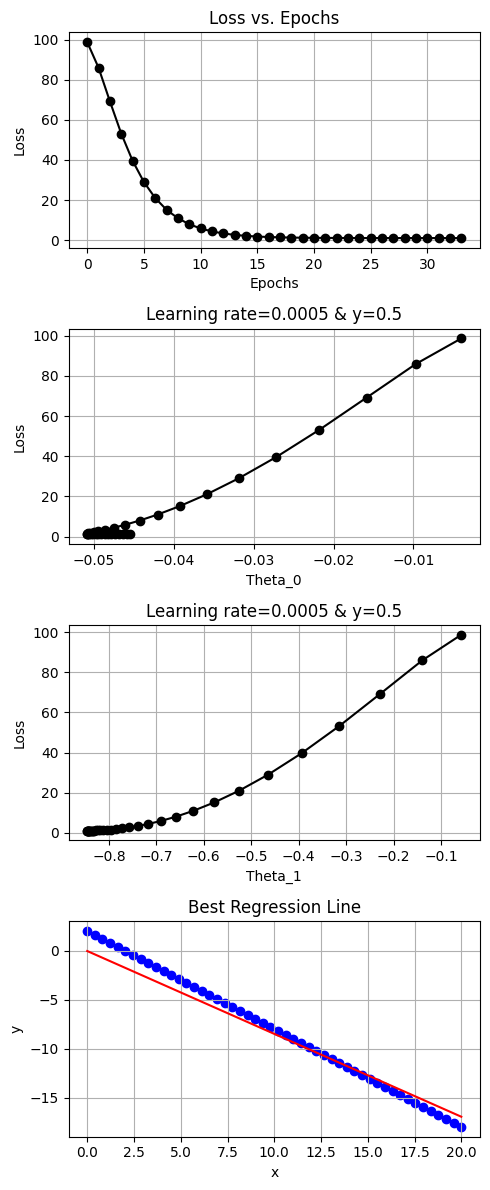

In [22]:
from matplotlib import markers
import matplotlib.pyplot as plt

fig,plots=plt.subplots(4,1,figsize=(5,12))
plots[0].plot(losses_history,color="k",marker="o",linestyle="-")
plots[0].set_title("Loss vs. Epochs")
plots[0].set_xlabel("Epochs")
plots[0].set_ylabel("Loss")
plots[0].grid(True)

plots[1].plot(theta0_history[1:],losses_history,color="k",marker="o",linestyle="-")
plots[1].set_title("Learning rate=0.0005 & y=0.5")
plots[1].set_xlabel("Theta_0")
plots[1].set_ylabel("Loss")
plots[1].grid(True)

plots[2].plot(theta1_history[1:],losses_history,color="k",marker="o",linestyle="-")
plots[2].set_title("Learning rate=0.0005 & y=0.5")
plots[2].set_xlabel("Theta_1")
plots[2].set_ylabel("Loss")
plots[2].grid(True)

plots[3].scatter(X,y,color="blue")
plots[3].plot(X,y_pred2,color="red")
plots[3].set_title("Best Regression Line")
plots[3].set_xlabel("x")
plots[3].set_ylabel("y")
plots[3].grid(True)

plt.tight_layout()
plt.show()

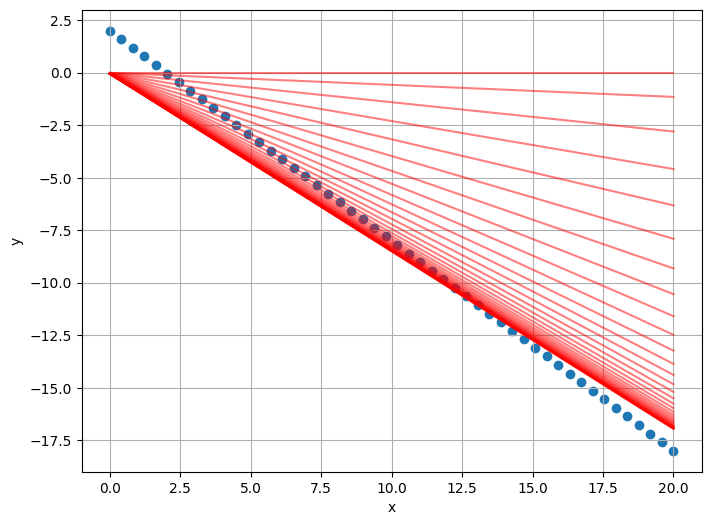

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_regression(x, y, theta0_history, theta1_history):
    plt.figure(figsize=(8, 6))

    plt.scatter(x, y, label='Data points')

    n_lines = len(theta0_history)
    step = max(1, n_lines // 50)

    for i in range(0, n_lines, step):
        y_pred = theta0_history[i] + theta1_history[i] * x
        plt.plot(x, y_pred, color='red', alpha=0.5)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()


plot_all_regression(X, y, theta0_history, theta1_history)

#### Try another values of momentum term and check your reults.
#### Try very large values close to one and very small values close to zero.
#### Try momentum = 0

##### The following results uses alpha = 0.0005, gamma=0.9 and max. iterations = 300.

In [24]:
theta0_history, theta1_history, losses_history, hyp, grad_norm, velocity_history= Momentum_GD(X,y,0.0005,0.9,300)


print("="*50)
for i in range(len(losses_history)):
    print(f"Iteration {i}")
    print(f"h(x): {hyp[i].flatten()}")
    print(f"Loss: {losses_history[i]}")
    print(f"Theta0: {theta0_history[i]}")
    print(f"Theta1: {theta1_history[i]}")
    print("-"*50)


Convergence Check Passed
Iteration 0
h(x): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
Loss: 98.69387755102042
Theta0: 0.0
Theta1: 0.0
--------------------------------------------------
Iteration 1
h(x): [-0.004      -0.02740691 -0.05081383 -0.07422074 -0.09762766 -0.12103457
 -0.14444148 -0.1678484  -0.19125531 -0.21466222 -0.23806914 -0.26147605
 -0.28488297 -0.30828988 -0.33169679 -0.35510371 -0.37851062 -0.40191753
 -0.42532445 -0.44873136 -0.47213828 -0.49554519 -0.5189521  -0.54235902
 -0.56576593 -0.58917284 -0.61257976 -0.63598667 -0.65939359 -0.6828005
 -0.70620741 -0.72961433 -0.75302124 -0.77642815 -0.79983507 -0.82324198
 -0.8466489  -0.87005581 -0.89346272 -0.91686964 -0.94027655 -0.96368347
 -0.98709038 -1.01049729 -1.03390421 -1.05731112 -1.08071803 -1.10412495
 -1.12753186 -1.15093878]
Loss: 85.92275965952962
Theta0: -0.003999999999999999
Theta1: -0.057346938775

In [25]:
y_pred3=theta0_history[-1]+theta1_history[-1]*X
r2_score(y,y_pred3)

0.9735481947368928

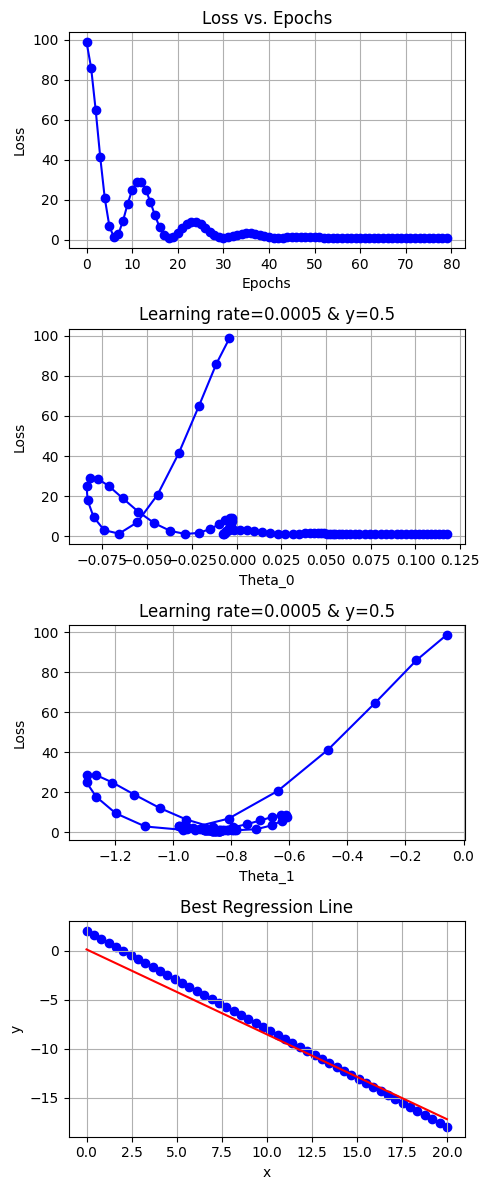

In [27]:
from matplotlib import markers
import matplotlib.pyplot as plt

fig,plots=plt.subplots(4,1,figsize=(5,12))
plots[0].plot(losses_history,color="b",marker="o",linestyle="-")
plots[0].set_title("Loss vs. Epochs")
plots[0].set_xlabel("Epochs")
plots[0].set_ylabel("Loss")
plots[0].grid(True)

plots[1].plot(theta0_history[1:],losses_history,color="b",marker="o",linestyle="-")
plots[1].set_title("Learning rate=0.0005 & y=0.5")
plots[1].set_xlabel("Theta_0")
plots[1].set_ylabel("Loss")
plots[1].grid(True)

plots[2].plot(theta1_history[1:],losses_history,color="b",marker="o",linestyle="-")
plots[2].set_title("Learning rate=0.0005 & y=0.5")
plots[2].set_xlabel("Theta_1")
plots[2].set_ylabel("Loss")
plots[2].grid(True)

plots[3].scatter(X,y,color="blue")
plots[3].plot(X,y_pred3,color="red")
plots[3].set_title("Best Regression Line")
plots[3].set_xlabel("x")
plots[3].set_ylabel("y")
plots[3].grid(True)

plt.tight_layout()
plt.show()

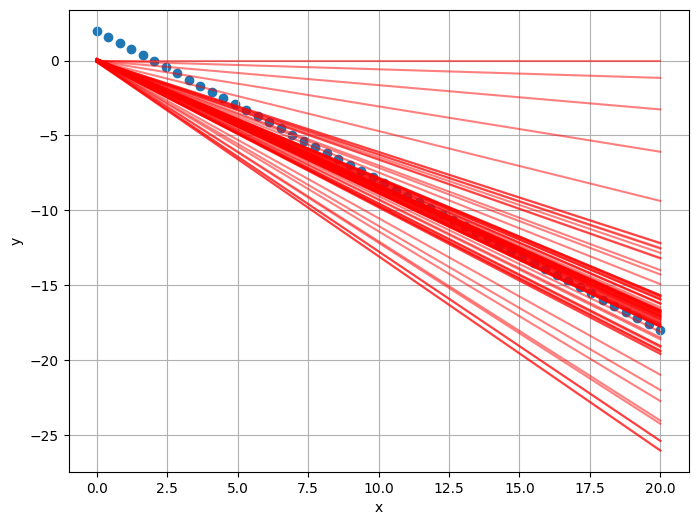

In [28]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_regression(x, y, theta0_history, theta1_history):
    plt.figure(figsize=(8, 6))

    plt.scatter(x, y, label='Data points')

    n_lines = len(theta0_history)
    step = max(1, n_lines // 50)

    for i in range(0, n_lines, step):
        y_pred = theta0_history[i] + theta1_history[i] * x
        plt.plot(x, y_pred, color='red', alpha=0.5)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()


plot_all_regression(X, y, theta0_history, theta1_history)

##### The following results uses alpha = 0.0005, gamma=0.89 and max. iterations = 300.

In [29]:
theta0_history, theta1_history, losses_history, hyp, grad_norm, velocity_history= Momentum_GD(X,y,0.0005,0.89,300)


print("="*50)
for i in range(len(losses_history)):
    print(f"Iteration {i}")
    print(f"h(x): {hyp[i].flatten()}")
    print(f"Loss: {losses_history[i]}")
    print(f"Theta0: {theta0_history[i]}")
    print(f"Theta1: {theta1_history[i]}")
    print("-"*50)


Convergence Check Passed
Iteration 0
h(x): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
Loss: 98.69387755102042
Theta0: 0.0
Theta1: 0.0
--------------------------------------------------
Iteration 1
h(x): [-0.004      -0.02740691 -0.05081383 -0.07422074 -0.09762766 -0.12103457
 -0.14444148 -0.1678484  -0.19125531 -0.21466222 -0.23806914 -0.26147605
 -0.28488297 -0.30828988 -0.33169679 -0.35510371 -0.37851062 -0.40191753
 -0.42532445 -0.44873136 -0.47213828 -0.49554519 -0.5189521  -0.54235902
 -0.56576593 -0.58917284 -0.61257976 -0.63598667 -0.65939359 -0.6828005
 -0.70620741 -0.72961433 -0.75302124 -0.77642815 -0.79983507 -0.82324198
 -0.8466489  -0.87005581 -0.89346272 -0.91686964 -0.94027655 -0.96368347
 -0.98709038 -1.01049729 -1.03390421 -1.05731112 -1.08071803 -1.10412495
 -1.12753186 -1.15093878]
Loss: 85.92275965952962
Theta0: -0.003999999999999999
Theta1: -0.057346938775

In [30]:
y_pred4=theta0_history[-1]+theta1_history[-1]*X

r2_score(y,y_pred4)

0.9723393985102275

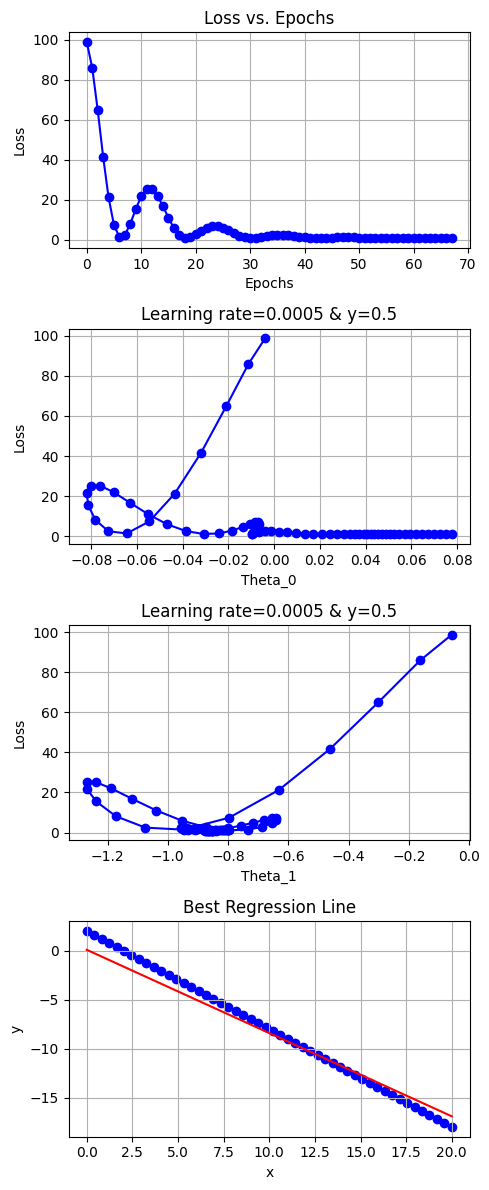

In [31]:
from matplotlib import markers
import matplotlib.pyplot as plt

fig,plots=plt.subplots(4,1,figsize=(5,12))
plots[0].plot(losses_history,color="b",marker="o",linestyle="-")
plots[0].set_title("Loss vs. Epochs")
plots[0].set_xlabel("Epochs")
plots[0].set_ylabel("Loss")
plots[0].grid(True)

plots[1].plot(theta0_history[1:],losses_history,color="b",marker="o",linestyle="-")
plots[1].set_title("Learning rate=0.0005 & y=0.5")
plots[1].set_xlabel("Theta_0")
plots[1].set_ylabel("Loss")
plots[1].grid(True)

plots[2].plot(theta1_history[1:],losses_history,color="b",marker="o",linestyle="-")
plots[2].set_title("Learning rate=0.0005 & y=0.5")
plots[2].set_xlabel("Theta_1")
plots[2].set_ylabel("Loss")
plots[2].grid(True)

plots[3].scatter(X,y,color="blue")
plots[3].plot(X,y_pred4,color="red")
plots[3].set_title("Best Regression Line")
plots[3].set_xlabel("x")
plots[3].set_ylabel("y")
plots[3].grid(True)

plt.tight_layout()
plt.show()

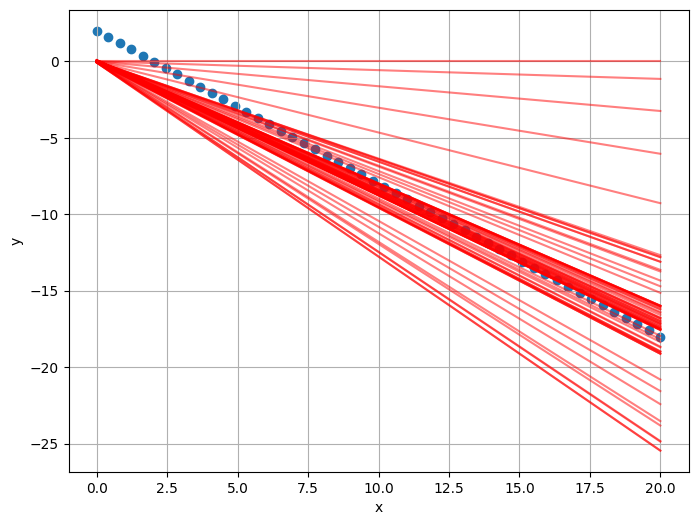

In [32]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_regression(x, y, theta0_history, theta1_history):
    plt.figure(figsize=(8, 6))

    plt.scatter(x, y, label='Data points')

    n_lines = len(theta0_history)
    step = max(1, n_lines // 50)

    for i in range(0, n_lines, step):
        y_pred = theta0_history[i] + theta1_history[i] * x
        plt.plot(x, y_pred, color='red', alpha=0.5)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()


plot_all_regression(X, y, theta0_history, theta1_history)

### Do not forget:

#### Try another values of momentum term and check your reults.
#### Try very large values close to one and very small values close to zero.
#### Try momentum = 0

### Update your Batch GD for one variable  implementation to be NAG and check your results

##### Very Important:
- <b><font color='red'> In order to calculate the gradient at theta_temp, you will need to calculate the prediction (hypothesis output) using theta_temp. </font></b>
##### h_temp = theta0_temp + theta1_temp * X

##### The following results uses alpha = 0.0005, gamma=0.9 and max. iterations = 300.

In [49]:
import numpy as np

def Nesterov_GD(X: np.array, y: np.array, alpha: float, gamma: float, max_iter: int):
    m = len(X)
    Xp = np.c_[np.ones((m, 1)), X]
    y = y.reshape(-1, 1)

    thetas = np.zeros((Xp.shape[1], 1))
    vt = np.zeros_like(thetas)

    losses_history = []
    theta0_history = [thetas[0, 0]]
    theta1_history = [thetas[1, 0]]
    velocity_history = []
    v0_history = []
    v1_history = []
    prev_err = 0


    for i in range(max_iter):

        thetas_lookahead = thetas - gamma * vt


        hypothesis_lookahead = Xp @ thetas_lookahead
        gradient_lookahead = (Xp.T @ (hypothesis_lookahead - y)) / m


        vt = gamma * vt + alpha * gradient_lookahead
        thetas -= vt

        v0_history.append(vt[0, 0])
        v1_history.append(vt[1, 0])
        velocity_history.append(vt.copy())
        loss = np.mean(((Xp @ thetas) - y) ** 2)
        losses_history.append(loss)
        theta0_history.append(thetas[0, 0])
        theta1_history.append(thetas[1, 0])


        if np.linalg.norm(gradient_lookahead) < 0.001:
            print(f"Gradient Check Passed at iteration {i}")
            break
        if i > 0 and np.abs(prev_err - loss) < 0.001:
            print(f"Convergence Check Passed at iteration {i}")
            break
        prev_err = loss


    hyp_final = Xp @ thetas
    grad_norm = np.linalg.norm(gradient_lookahead)

    return theta0_history, theta1_history, losses_history, hyp_final, grad_norm, velocity_history, v0_history, v1_history

In [50]:
theta0_history, theta1_history, losses_history, hyp_final, grad_norm, velocity_history, v0_history, v1_history = Nesterov_GD(X,y,0.0005,0.9,300)


print("="*50)
for i in range(len(losses_history)):
    print(f"Iteration {i}")
    print(f"Loss: {losses_history[i]}")
    print(f"Theta0: {theta0_history[i]}")
    print(f"Theta1: {theta1_history[i]}")
    print(f"V0: {v0_history[i]}")
    print(f"v1: {v1_history[i]}")
    print("-"*50)

print(f"Final Hypothesis (First 5 predictions): \n{hyp_final[:5].flatten()}")

Convergence Check Passed at iteration 47
Iteration 0
Loss: 85.92275965952962
Theta0: 0.0
Theta1: 0.0
V0: 0.003999999999999999
v1: 0.05734693877551021
--------------------------------------------------
Iteration 1
Loss: 65.49789734140406
Theta0: -0.003999999999999999
Theta1: -0.05734693877551021
V0: 0.007051404081632653
v1: 0.1015831162015827
--------------------------------------------------
Iteration 2
Loss: 43.18048939270758
Theta0: -0.011051404081632653
Theta1: -0.1589300549770929
V0: 0.009085790541799251
v1: 0.13182412161932022
--------------------------------------------------
Iteration 3
Loss: 23.730196882412336
Theta0: -0.020137194623431904
Theta1: -0.2907541765964131
V0: 0.010116074854294796
v1: 0.14827551652933205
--------------------------------------------------
Iteration 4
Loss: 9.999100015165048
Theta0: -0.030253269477726698
Theta1: -0.43902969312574514
V0: 0.0102224002104313
v1: 0.15204349718385823
--------------------------------------------------
Iteration 5
Loss: 2.766

In [51]:
y_pred5=theta0_history[-1]+theta1_history[-1]*X
r2_score(y,y_pred)

0.9851254759827675

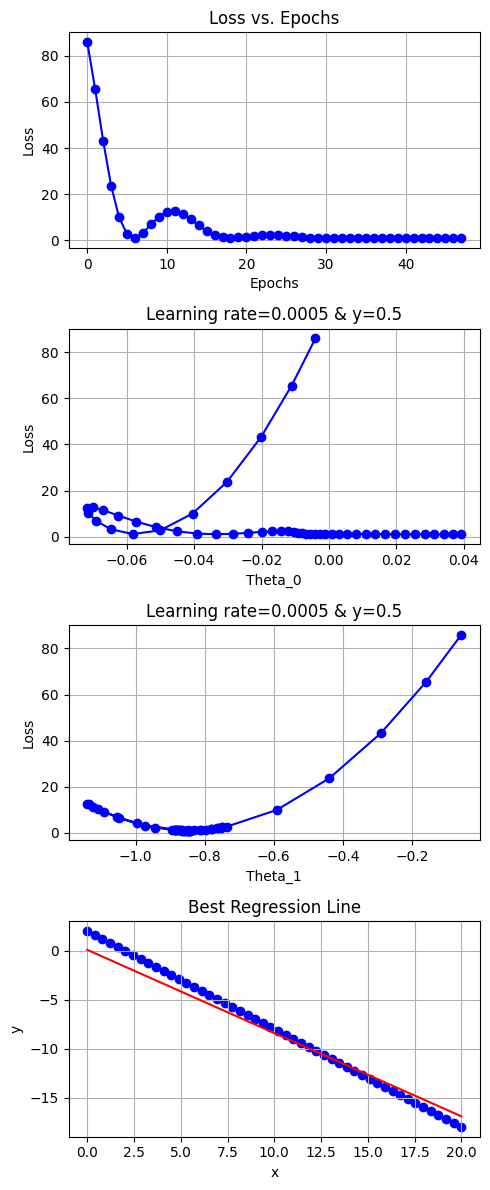

In [53]:
from matplotlib import markers
import matplotlib.pyplot as plt

fig,plots=plt.subplots(4,1,figsize=(5,12))
plots[0].plot(losses_history,color="b",marker="o",linestyle="-")
plots[0].set_title("Loss vs. Epochs")
plots[0].set_xlabel("Epochs")
plots[0].set_ylabel("Loss")
plots[0].grid(True)

plots[1].plot(theta0_history[1:],losses_history,color="b",marker="o",linestyle="-")
plots[1].set_title("Learning rate=0.0005 & y=0.5")
plots[1].set_xlabel("Theta_0")
plots[1].set_ylabel("Loss")
plots[1].grid(True)

plots[2].plot(theta1_history[1:],losses_history,color="b",marker="o",linestyle="-")
plots[2].set_title("Learning rate=0.0005 & y=0.5")
plots[2].set_xlabel("Theta_1")
plots[2].set_ylabel("Loss")
plots[2].grid(True)

plots[3].scatter(X,y,color="blue")
plots[3].plot(X,y_pred4,color="red")
plots[3].set_title("Best Regression Line")
plots[3].set_xlabel("x")
plots[3].set_ylabel("y")
plots[3].grid(True)

plt.tight_layout()
plt.show()

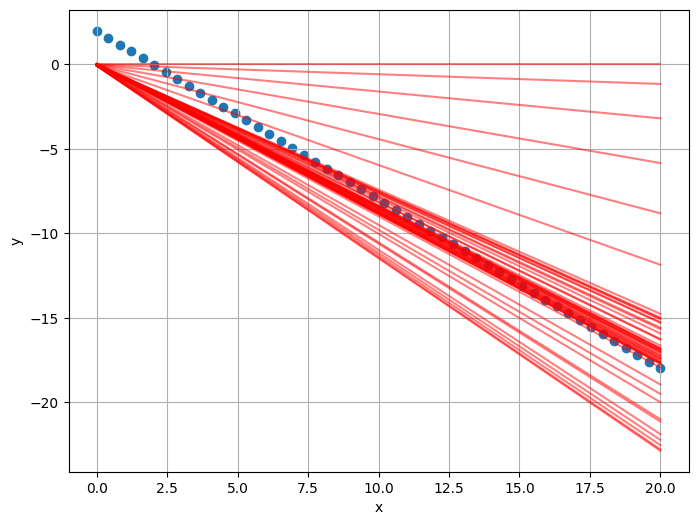

In [56]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_regression(x, y, theta0_history, theta1_history):
    plt.figure(figsize=(8, 6))

    plt.scatter(x, y, label='Data points')

    n_lines = len(theta0_history)
    step = max(1, n_lines // 50)

    for i in range(0, n_lines, step):
        y_pred = theta0_history[i] + theta1_history[i] * x
        plt.plot(x, y_pred, color='red', alpha=0.5)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()


plot_all_regression(X, y, theta0_history, theta1_history)

##### The following results uses alpha = 0.0005, gamma=0.89 and max. iterations = 300.

In [57]:
theta0_history, theta1_history, losses_history, hyp_final, grad_norm, velocity_history, v0_history, v1_history = Nesterov_GD(X,y,0.0005,0.89,300)


print("="*50)
for i in range(len(losses_history)):
    print(f"Iteration {i}")
    print(f"Loss: {losses_history[i]}")
    print(f"Theta0: {theta0_history[i]}")
    print(f"Theta1: {theta1_history[i]}")
    print(f"V0: {v0_history[i]}")
    print(f"v1: {v1_history[i]}")
    print("-"*50)

print(f"Final Hypothesis (First 5 predictions): \n{hyp_final[:5].flatten()}")

Convergence Check Passed at iteration 31
Iteration 0
Loss: 85.92275965952962
Theta0: 0.0
Theta1: 0.0
V0: 0.003999999999999999
v1: 0.05734693877551021
--------------------------------------------------
Iteration 1
Loss: 65.59804446776275
Theta0: -0.003999999999999999
Theta1: -0.05734693877551021
V0: 0.007014291428571429
v1: 0.10104846822157434
--------------------------------------------------
Iteration 2
Loss: 43.46691611862568
Theta0: -0.011014291428571427
Theta1: -0.15839540699708454
V0: 0.008992448147457144
v1: 0.13046962320897376
--------------------------------------------------
Iteration 3
Loss: 24.189191790185106
Theta0: -0.02000673957602857
Theta1: -0.2888650302060583
V0: 0.009964358867713002
v1: 0.14605048837926363
--------------------------------------------------
Iteration 4
Loss: 10.497770193524975
Theta0: -0.029971098443741573
Theta1: -0.43491551858532196
V0: 0.010024357437132236
v1: 0.1490933603050695
--------------------------------------------------
Iteration 5
Loss: 3.

In [58]:
y_pred5=theta0_history[-1]+theta1_history[-1]*X
r2_score(y,y_pred)

0.9851254759827675

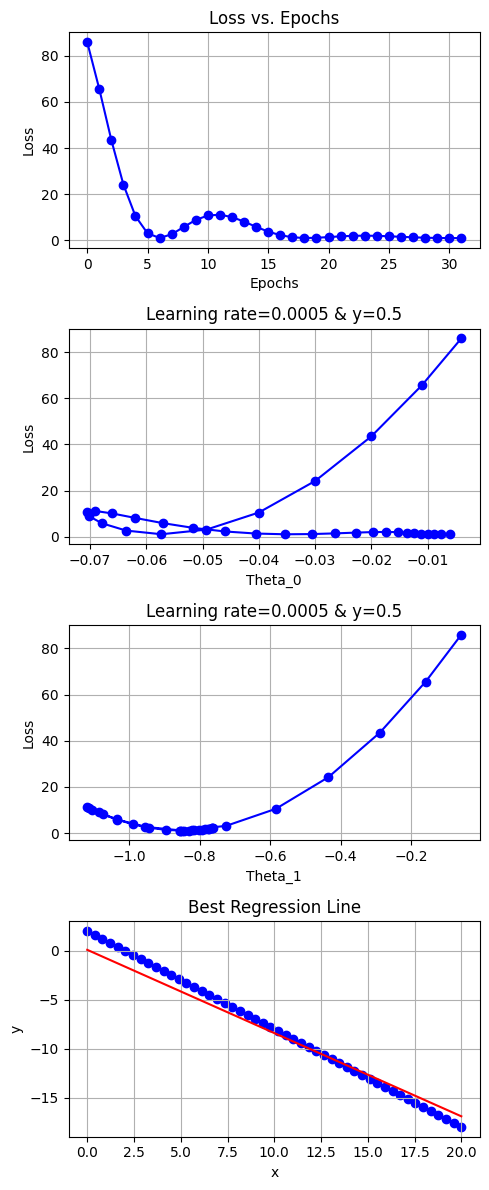

In [59]:
from matplotlib import markers
import matplotlib.pyplot as plt

fig,plots=plt.subplots(4,1,figsize=(5,12))
plots[0].plot(losses_history,color="b",marker="o",linestyle="-")
plots[0].set_title("Loss vs. Epochs")
plots[0].set_xlabel("Epochs")
plots[0].set_ylabel("Loss")
plots[0].grid(True)

plots[1].plot(theta0_history[1:],losses_history,color="b",marker="o",linestyle="-")
plots[1].set_title("Learning rate=0.0005 & y=0.5")
plots[1].set_xlabel("Theta_0")
plots[1].set_ylabel("Loss")
plots[1].grid(True)

plots[2].plot(theta1_history[1:],losses_history,color="b",marker="o",linestyle="-")
plots[2].set_title("Learning rate=0.0005 & y=0.5")
plots[2].set_xlabel("Theta_1")
plots[2].set_ylabel("Loss")
plots[2].grid(True)

plots[3].scatter(X,y,color="blue")
plots[3].plot(X,y_pred4,color="red")
plots[3].set_title("Best Regression Line")
plots[3].set_xlabel("x")
plots[3].set_ylabel("y")
plots[3].grid(True)

plt.tight_layout()
plt.show()

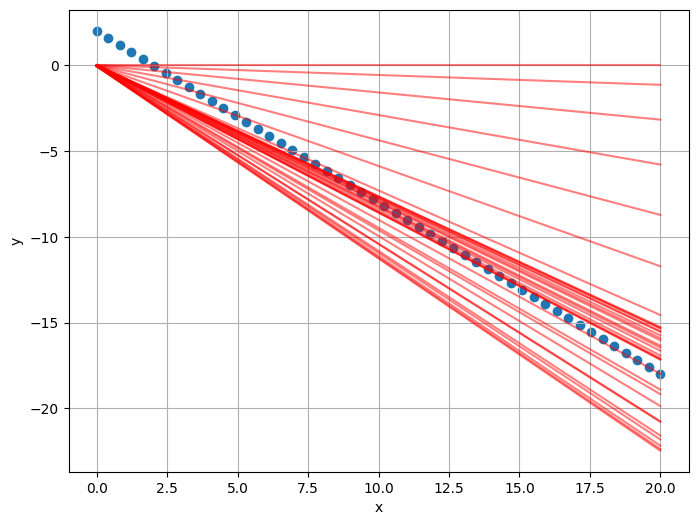

In [60]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_regression(x, y, theta0_history, theta1_history):
    plt.figure(figsize=(8, 6))

    plt.scatter(x, y, label='Data points')

    n_lines = len(theta0_history)
    step = max(1, n_lines // 50)

    for i in range(0, n_lines, step):
        y_pred = theta0_history[i] + theta1_history[i] * x
        plt.plot(x, y_pred, color='red', alpha=0.5)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.show()


plot_all_regression(X, y, theta0_history, theta1_history)